## Regression Model for Students GPA Predictor

### Description:

In the classification model I built a model to identify students at risk of dropping out. In this notebook, for the students already flagged as dropout risk, I want to predict their GPA and more importantly understand what is causing their low performance.

This is not just a prediction exercise. The most valuable output of this notebook is the feature importance analysis. By grouping features into categories like financial stress, academic struggles, and personal background, I can give advisors a starting point for deciding what kind of support to offer each student.

The regression model is only trained and applied on students the classification model flagged as at risk.

**Priority Metric:** RMSE and R² to evaluate prediction quality, but the feature importance grouped by category is the main deliverable.


## 1.0 Setup

The same setup pattern as the classification notebook. Set `running_local = False` when running on Google Colab.

In [1]:
running_local = True

## 1.1 Import  libraries

In [2]:
# utils folder is in the root, the notebook cannot unless the root path is added to the notebook.
############ import utils from if running from local machine ###########
if running_local:
    import sys
    import os
    sys.path.append('..')
    from utils.data_utils import evaluate_classification_model, get_model_metrics, predict_with_threshold, evaluate_regression_model
else:
    ###############################################################

    ################################################################
    ####################### GOOGLE COLAB RUN #######################
    ### Utils file is not available if running on Colab. I need to clone the repo to use the data_utils.py
    !git clone https://github.com/weslylaboy/student-outcome-predictor.git
    import sys
    sys.path.insert(0, '/content/student-outcome-predictor')
    from utils.data_utils import evaluate_classification_model, get_model_metrics, predict_with_threshold, evaluate_regression_model
    ###############################################################

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import joblib
import warnings
warnings.filterwarnings('ignore')


***Interpretation:*** The imports are simpler than the classification notebook. I'm going to build a Linear Regression, Ridge and Lasso, Random Forest, and XGBoost. There is no SMOTE here because class imbalance is a classification concern. `StandardScaler` is added for numerical features because Ridge and Lasso are sensitive to feature scale.


## 1.2 Load data

I load the same cleaned dataset from the preprocessing phase and the saved classification model from notebook 03. The classification model is what I will use to identify which students are at risk before doing anything else.


In [11]:
if running_local:
    df = pd.read_csv('../data/processed/02.7_data_final.csv')
    clf_model = joblib.load('../models/student_outcome_prediction_model.joblib')
else:
    df = pd.read_csv('/content/student-outcome-predictor/data/processed/02.7_data_final.csv')
    clf_model = joblib.load('/content/student-outcome-predictor/models/student_outcome_prediction_model.joblib')

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   marital_status                   4424 non-null   int64  
 1   application_mode                 4424 non-null   int64  
 2   application_order                4424 non-null   int64  
 3   course                           4424 non-null   int64  
 4   daytime_evening                  4424 non-null   int64  
 5   prev_qualification               4424 non-null   int64  
 6   prev_grade                       4424 non-null   float64
 7   nationality                      4424 non-null   int64  
 8   mother_qualification             4424 non-null   int64  
 9   father_qualification             4424 non-null   int64  
 10  mother_occupation                4424 non-null   int64  
 11  father_occupation                4424 non-null   int64  
 12  admission_grade     

***Interpretation:*** I have loaded both the dataset and the classification model. The classification model was saved at the end of notebook 03 and I need it here to generate dropout probabilities for each student. The dataset has `47 columns` and the `target` for this notebook is `cu2_grade`, which is the average grade a student got in their second semester on a scale from `0 to 20`.


### 1.3 Fix Data type

In [12]:
# Fix int datatypes
int_cols = ['displaced', 'special_needs', 'debtor', 'tuition_fees_up_to_date', 'gender', 'scholarship_holder', 'international', 'daytime_evening', 'age_at_enrollment', 'cu1_credited', 'cu1_enrolled', 'cu1_evaluations', 'cu1_approved', 'cu1_no_evaluations', 'cu2_credited', 'cu2_enrolled', 'cu2_evaluations', 'cu2_approved', 'cu2_no_evaluations', 'total_approved_units', 'prev_qualification']
df[int_cols] = df[int_cols].astype('int8')

# additional engineered features
unknown_flags = [
    'father_occupation_is_unknown', 'mother_occupation_is_unknown',
    'father_qualification_is_unknown', 'mother_qualification_is_unknown',
    'prev_qualification_is_unknown',
    'any_info_missing'
]

df[unknown_flags] = df[unknown_flags].astype('int8')

# target variable
df['target_encoded'] = df['target_encoded'].astype('int8')


####### Fix binary data types
categorical_cols = [
    'marital_status',
    'application_mode',
    'application_order',
    'course',
    'nationality',
    'mother_qualification',
    'father_qualification',
    'mother_occupation',
    'father_occupation'
]
df[categorical_cols] = df[categorical_cols].astype('category')

# new engineered feature as category
df['age_group'] = df['age_group'].astype('category')

df.info()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   marital_status                   4424 non-null   category
 1   application_mode                 4424 non-null   category
 2   application_order                4424 non-null   category
 3   course                           4424 non-null   category
 4   daytime_evening                  4424 non-null   int8    
 5   prev_qualification               4424 non-null   int8    
 6   prev_grade                       4424 non-null   float64 
 7   nationality                      4424 non-null   category
 8   mother_qualification             4424 non-null   category
 9   father_qualification             4424 non-null   category
 10  mother_occupation                4424 non-null   category
 11  father_occupation                4424 non-null   category
 12  admiss

,marital_status,application_mode,application_order,course,daytime_evening,prev_qualification,prev_grade,nationality,mother_qualification,father_qualification,...,father_occupation_is_unknown,mother_occupation_is_unknown,father_qualification_is_unknown,mother_qualification_is_unknown,prev_qualification_is_unknown,any_info_missing,target_encoded,age_group,grade_progression,total_approved_units
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0,0,0,18-21,0.000000,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,0,0,0,0,0,2,18-21,-0.333333,12
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,0,0,0,0,0,18-21,0.000000,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,0,0,0,0,2,18-21,-1.028571,11
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,0,0,0,0,2,31+,0.666667,11


***Interpretation:*** I have fix the datatypes for all columns in dataset.

## 2.0 Filter At Risk Students

This regression model is not meant for all students. It is specifically for students the classification model already identified as dropout risks. The logic is:

1. The classification model tells us who is at risk
2. This regression model then asks: among those students, how is their academic performance and what is causing it

I will also remove invalid grade for students with `cu2_grade = 0`. Those are mostly students who dropped out and never took the exams, so their zero does not represent actual academic performance, it just means they stopped attending.

I will also use the same threshold of `0.4` used for the classification method. This threshold will be used to capture the students with `40%` probability of dropping out.


In [14]:
target = 'cu2_grade'

# filter invalid grade cu_grade = 0
df_valid = df[df[target] > 0].copy()

# get dropout probability from the classification model for all valid students
dropout_proba = clf_model.predict_proba(df_valid)[:, 0]
df_valid['dropout_probability'] = dropout_proba

# Keep only students flagged as at risk (dropout probability >= 0.4)
df_at_risk = df_valid[df_valid['dropout_probability'] >= 0.4].copy()

print(f"Total students in dataset           : {len(df)}")
print(f"Students with valid cu2_grade       : {len(df_valid)}")
print(f"Students flagged as dropout risk    : {len(df_at_risk)}")
print(f"\nGrade distribution for at risk students:")
df_at_risk[target].describe().round(4)


Total students in dataset           : 4424
Students with valid cu2_grade       : 3554
Students flagged as dropout risk    : 1011

Grade distribution for at risk students:


count    1011.0000
mean       11.9618
std         1.3608
min        10.0000
25%        11.0000
50%        11.7500
75%        12.8000
max        17.4286
Name: cu2_grade, dtype: float64

***Interpretation:*** The classification model found that the dataset contains `4,424` students. From those students, `3,554` had a valid target variable (`cu2_grade`), it must be a positive non-zero number. A value of `0` for `cu2_grade` indicate the student stop showing up to classes. The model classified `1,011` students at risk of dropout.

The grade `cu2_grade` goes from `0 to 20`, for the students flagged as risk the `mean` is `11.96`, the `min` value is `10.00`, and the `max` is `17.43`. The `std` is `1.36`, and the `50%` of student as risk are about `11.75`.

## 2.2 Correlation between Features and Target Variable

Before building any model I want to understand the correlation between the features an the target variable `cu2_grade`.


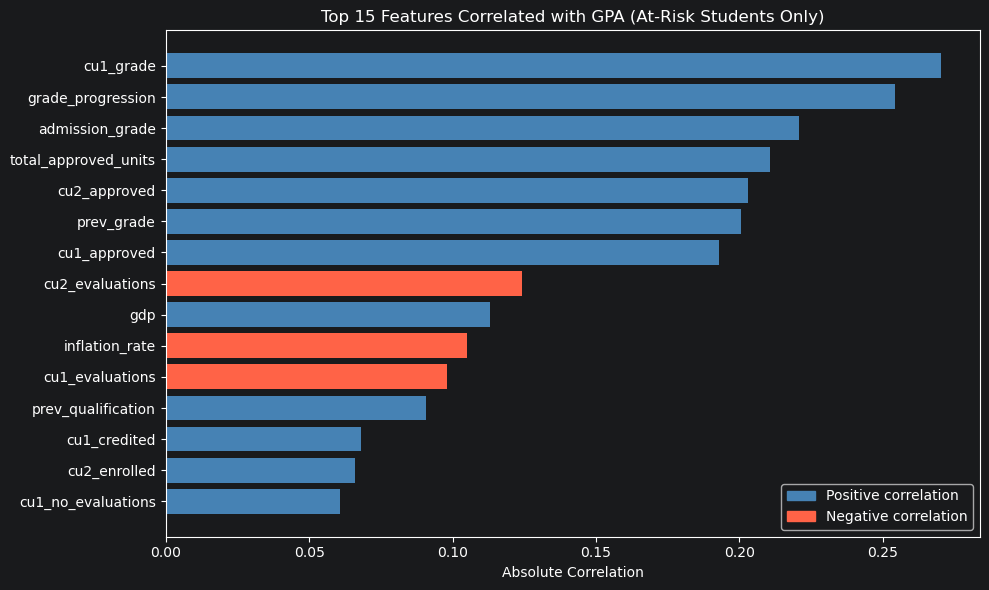


Top 10 correlated features:
cu1_grade               0.2703
grade_progression       0.2543
admission_grade         0.2206
total_approved_units    0.2108
cu2_approved            0.2030
prev_grade              0.2004
cu1_approved            0.1930
cu2_evaluations         0.1243
gdp                     0.1130
inflation_rate          0.1049
Name: cu2_grade, dtype: float64


In [15]:
# Correlation of numerical features with GPA for at-risk students only
numeric_cols = df_at_risk.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in [target, 'target_encoded', 'dropout_probability']]

correlations = df_at_risk[numeric_cols + [target]].corr()[target].drop(target)
top_corr = correlations.abs().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if correlations[f] > 0 else 'tomato' for f in top_corr.index]
ax.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1])
ax.set_title('Top 15 Features Correlated with GPA (At-Risk Students Only)', fontsize=12)
ax.set_xlabel('Absolute Correlation')
blue_patch = mpatches.Patch(color='steelblue', label='Positive correlation')
red_patch  = mpatches.Patch(color='tomato',    label='Negative correlation')
ax.legend(handles=[blue_patch, red_patch])
plt.tight_layout()
plt.savefig('../plots/04_gpa_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 correlated features:")
print(correlations.abs().sort_values(ascending=False).head(10).round(4))


***Interpretation:*** Among students flagged as dropout risk, the strongest relationships with GPA are academic variables, especially `cu1_grade`, `grade_progression`, `admission_grade`, `total_approved_units`, `cu2_approved`, and `prev_grade` which have possitive correlation.

The negative correlation with the target variable are `cu2_evaluation`, `inflation_rate`, and `cu_evaluation`. The negative correlation with `inflation_rate` could suggests that in periods of high inflation, students in may have slightly worse GPA, possibly because financial pressure affects study stability.

A negative correlation does not mean the variable causes low GPA. It means the two move in opposite directions in this subgroup. For example, more evaluations may not lower GPA by itself; instead, students with weaker performance may receive more evaluations



## 3.0 Separate Features and Target Variable

In [19]:
target = 'cu2_grade'

# Features available before the target is known
regression_features = [
    'marital_status',
    'application_mode',
    'application_order',
    'course',
    'daytime_evening',
    'prev_qualification',
    'prev_grade',
    'nationality',
    'mother_qualification',
    'father_qualification',
    'mother_occupation',
    'father_occupation',
    'admission_grade',
    'displaced',
    'special_needs',
    'debtor',
    'tuition_fees_up_to_date',
    'gender',
    'scholarship_holder',
    'age_at_enrollment',
    'international',
    'cu1_credited',
    'cu1_enrolled',
    'cu1_evaluations',
    'cu1_approved',
    'cu1_grade',
    'cu1_no_evaluations',
    'unemployment_rate',
    'inflation_rate',
    'gdp',
    'father_occupation_is_unknown',
    'mother_occupation_is_unknown',
    'father_qualification_is_unknown',
    'mother_qualification_is_unknown',
    'prev_qualification_is_unknown',
    'any_info_missing',
    'age_group',
    'cu2_grade'
]

# df = df[regression_features]
# df.info()

df_at_risk = df_at_risk[regression_features]


X = df_at_risk.drop(columns=['cu2_grade'])
y = df_at_risk['cu2_grade']

X.shape, y.shape

((1011, 37), (1011,))

***Interpretation***: The features and target variable was separated into different variables. I also removed `cu2_grade`, `target`, `target_encoded`, and `dropout_probability` since those are targets or outputs from the previous model, not inputs. The dataset now have `1,011 rows` and `44 features` while the target variable has `1,011` rows.


### 3.1 Train-Test split

In this step, I will split the student at risk data into training and test sets.


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set : {X_train.shape[0]} students")
print(f"Test set     : {X_test.shape[0]} students")


Training set : 808 students
Test set     : 203 students


***Interpretation*** The training set have `808` students, and the test set have `203` students.

## 4.0 Build Preprocessing Pipeline

Now, I will build a `ColumnTransformer` that scales numerical features, passes binary features through, and one hot encodes the categorical ones. This object will be inside every model pipeline.


In [21]:
print('cu2_grade' in X_train.columns)
print(X_train.columns.tolist())

False
['marital_status', 'application_mode', 'application_order', 'course', 'daytime_evening', 'prev_qualification', 'prev_grade', 'nationality', 'mother_qualification', 'father_qualification', 'mother_occupation', 'father_occupation', 'admission_grade', 'displaced', 'special_needs', 'debtor', 'tuition_fees_up_to_date', 'gender', 'scholarship_holder', 'age_at_enrollment', 'international', 'cu1_credited', 'cu1_enrolled', 'cu1_evaluations', 'cu1_approved', 'cu1_grade', 'cu1_no_evaluations', 'unemployment_rate', 'inflation_rate', 'gdp', 'father_occupation_is_unknown', 'mother_occupation_is_unknown', 'father_qualification_is_unknown', 'mother_qualification_is_unknown', 'prev_qualification_is_unknown', 'any_info_missing', 'age_group']


In [24]:

numeric_features = [
    'prev_grade', 'admission_grade', 'age_at_enrollment',
    'cu1_credited', 'cu1_enrolled', 'cu1_evaluations',
    'cu1_approved', 'cu1_grade', 'cu1_no_evaluations',
    'unemployment_rate', 'inflation_rate', 'gdp'
]

binary_features = [
    'displaced', 'special_needs', 'debtor', 'tuition_fees_up_to_date',
    'gender', 'scholarship_holder', 'international',
    'father_occupation_is_unknown', 'mother_occupation_is_unknown',
    'father_qualification_is_unknown', 'mother_qualification_is_unknown',
    'prev_qualification_is_unknown', 'any_info_missing'
]

categorical_features = [
    'marital_status', 'application_mode', 'application_order', 'course',
    'daytime_evening', 'prev_qualification', 'nationality',
    'mother_qualification', 'father_qualification',
    'mother_occupation', 'father_occupation', 'age_group'
]


preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', StandardScaler(), numeric_features),
        ('binary', 'passthrough', binary_features),
        ('categorical', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='drop'
)

preprocessor

ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                 ['prev_grade', 'admission_grade',
                                  'age_at_enrollment', 'cu1_credited',
                                  'cu1_enrolled', 'cu1_evaluations',
                                  'cu1_approved', 'cu1_grade',
                                  'cu1_no_evaluations', 'unemployment_rate',
                                  'inflation_rate', 'gdp']),
                                ('binary', 'passthrough',
                                 ['displaced', 'special_needs', 'debtor',
                                  'tuition_fees_up_to_date', 'gender...
                                  'prev_qualification_is_unknown',
                                  'any_info_missing']),
                                ('categorical',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['marital_status', 'application_mode',
                                  'application_order', 'course',
                                  'daytime_evening', 'prev_qualification',
                                  'nationality', 'mother_qualification',
                                  'father_qualification', 'mother_occupation',
                                  'father_occupation', 'age_group'])])

***Interpretation:*** `StandardScaler` is important here because Ridge and Lasso use regularization penalties that assume features are on a similar scale. A feature like `gdp` in the thousands would dominate over `cu1_grade` on a `0 to 20` scale if I do not normalize first. Binary features are already `0 or 1` so they do not need scaling. `course` gets one hot encoded with `drop='first'` to avoid perfectly correlated columns.


## 5.0 Linear Regression (Baseline Model)


I start with the simplest possible model. Linear Regression assumes `cu2_grade` (GPA) is a linear combination of the input features. It has no hyperparameters to tune.


In [25]:
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

results = {}

lr_pipe = evaluate_regression_model('Linear Regression', lr_pipe, X_train, y_train, X_test, y_test, results)

print(results)


[Linear Regression] RMSE: 1.3504 | MAE: 1.0634 | R²: -0.0795
{'Linear Regression': {'RMSE': np.float64(1.3504), 'MAE': 1.0634, 'R²': -0.0795}}


***Interpretation:*** This model is not learning much from the current feature set. The negative `R<sup>2</sup>` suggests the model performs worse that predicting the mean of the GPA for every student. A `RMSE =1.3504` means predictions are off by `1.35 GPA`. The `MAE=1.0634` means the absolute prediction error is about `1.06 GPA`. This linear regression model is not capturing well GPA of students, this means a Linear Regression model is not going to work for this dataset. I need a more complicated model because a simple linear relationship is not going to work for this dataset.